# Reading GRIN2B NWB Files

This notebook demonstrates how to read the converted GRIN2B NWB files from the Gonzalez-Sulser Lab. Each NWB file covers **one subject's full raw recording**, with the BL1/BL2 baseline windows marked in the epochs table (not split across files). It covers:

1. Loading the NWB file and inspecting top-level metadata, including the BL1/BL2 epochs table
2. Reading raw EEG/EMG acquisition data (full recording)
3. Reading sleep-state epoch annotations (BL1)
4. Reading seizure event intervals (BL1)
5. Reading per-epoch spike-wave discharge (SWD) counts (BL1)
6. Reading per-sleep-state power spectra (BL1)

**Prerequisites:** `pynwb`, `matplotlib`, `numpy`, `pandas`

```bash
conda activate gonzalez-sulser-lab-to-nwb-env
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO

# Update this path to the location of your NWB file.
# One NWB file now covers the subject's full recording (both BL1 and BL2).
# subject_id uses a dash (GRIN2B-<id>), not the underscore used for the lab's
# on-disk file/folder naming (GRIN2B_<id>).
NWB_PATH = Path(
    "H:/gonzalez-nwbfiles/sub-GRIN2B-129/sub-GRIN2B-129_ses-2021-03-26_ecephys.nwb"
)

## 1. Load and inspect top-level metadata

In [2]:
io = NWBHDF5IO(NWB_PATH, mode="r")
nwb = io.read()

print(f"Session ID:          {nwb.session_id}")
print(f"Session start time:  {nwb.session_start_time}")
print(f"Institution:         {nwb.institution}")
print(f"Lab:                 {nwb.lab}")
print(f"Subject ID:          {nwb.subject.subject_id}")
print(f"Subject species:     {nwb.subject.species}")
print()
print("Acquisition keys:", list(nwb.acquisition.keys()))
print("Processing modules:", list(nwb.processing.keys()))

epochs_df = nwb.epochs.to_dataframe()
print()
print("Baseline windows 1 and 2 are marked in the NWB epochs table (seconds relative to session_start_time)")
epochs_df[:]
bl1_start_time = epochs_df["start_time"][0]
bl2_start_time = epochs_df["start_time"][1]

Session ID:          2021-03-26
Session start time:  2021-03-26 10:55:59.996006+00:00
Institution:         University of Edinburgh
Lab:                 Gonzalez-Sulser Lab
Subject ID:          GRIN2B-129
Subject species:     Rattus norvegicus

Acquisition keys: ['EEGElectricalSeries', 'EMGElectricalSeries']
Processing modules: ['behavior', 'ecephys']

Baseline windows 1 and 2 are marked in the NWB epochs table (seconds relative to session_start_time)


## 2. Raw EEG / EMG

The **full raw recording** is stored as **two** `ElectricalSeries` in `acquisition` — one for
EEG, one for EMG — sharing a single electrode table but linked to distinct `ElectrodeGroup`s.
Both start at `starting_time = 0` (i.e. `session_start_time`); the BL1/BL2 windows within them
are given by the epochs table above, not by slicing the raw data:

- `EEGElectricalSeries`: **14 EEG channels** — bilateral cortex — S1_Tr, M2_Fra, M2_anterior, M1_anterior, V2_ML, V1_M, S1Hl_S1Fl (Right + Left)
- `EMGElectricalSeries`: **2 EMG channels** — Right and Left

In [3]:
eeg_es = nwb.acquisition["EEGElectricalSeries"]
emg_es = nwb.acquisition["EMGElectricalSeries"]

for name, es in [("EEG", eeg_es), ("EMG", emg_es)]:
    print(f"--- {name} ---")
    print(f"ElectricalSeries shape:  {es.data.shape}")
    print(f"Sampling rate:           {es.rate} Hz")
    print(f"Starting time:           {es.starting_time:.2f} s (= session_start_time; full recording)")
    print(f"Duration:                {es.data.shape[0] / es.rate / 3600:.2f} h")
    print(f"Conversion (to volts):   {es.conversion:.6e}")
    print()

electrodes = nwb.electrodes.to_dataframe()
electrodes[:]

--- EEG ---
ElectricalSeries shape:  (69391534, 14)
Sampling rate:           250.4 Hz
Starting time:           0.00 s (= session_start_time; full recording)
Duration:                76.98 h
Conversion (to volts):   3.173828e-06

--- EMG ---
ElectricalSeries shape:  (69391534, 2)
Sampling rate:           250.4 Hz
Starting time:           0.00 s (= session_start_time; full recording)
Duration:                76.98 h
Conversion (to volts):   3.173828e-06



,location,group,group_name,channel_name,rel_y,hemisphere,rel_x,filtering
id,,,,,,,,
0,S1_Tr,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,S1_Tr_R,2.8,R,-3.0,none
1,M2_Fra,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,M2_Fra_R,1.2,R,3.6,none
2,M2_anterior,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,M2_anterior_R,1.2,R,1.5,none
3,M1_anterior,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,M1_anterior_R,2.8,R,1.5,none
4,V2_ML,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,V2_ML_R,3.0,R,-5.0,none
5,V1_M,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,V1_M_R,3.0,R,-7.0,none
6,S1Hl_S1Fl,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,S1Hl_S1Fl_R,2.8,R,-1.0,none
7,V1_M,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,V1_M_L,3.0,L,-7.0,none
8,V2_ML,EEGArray pynwb.ecephys.ElectrodeGroup at 0x131...,EEGArray,V2_ML_L,3.0,L,-5.0,none


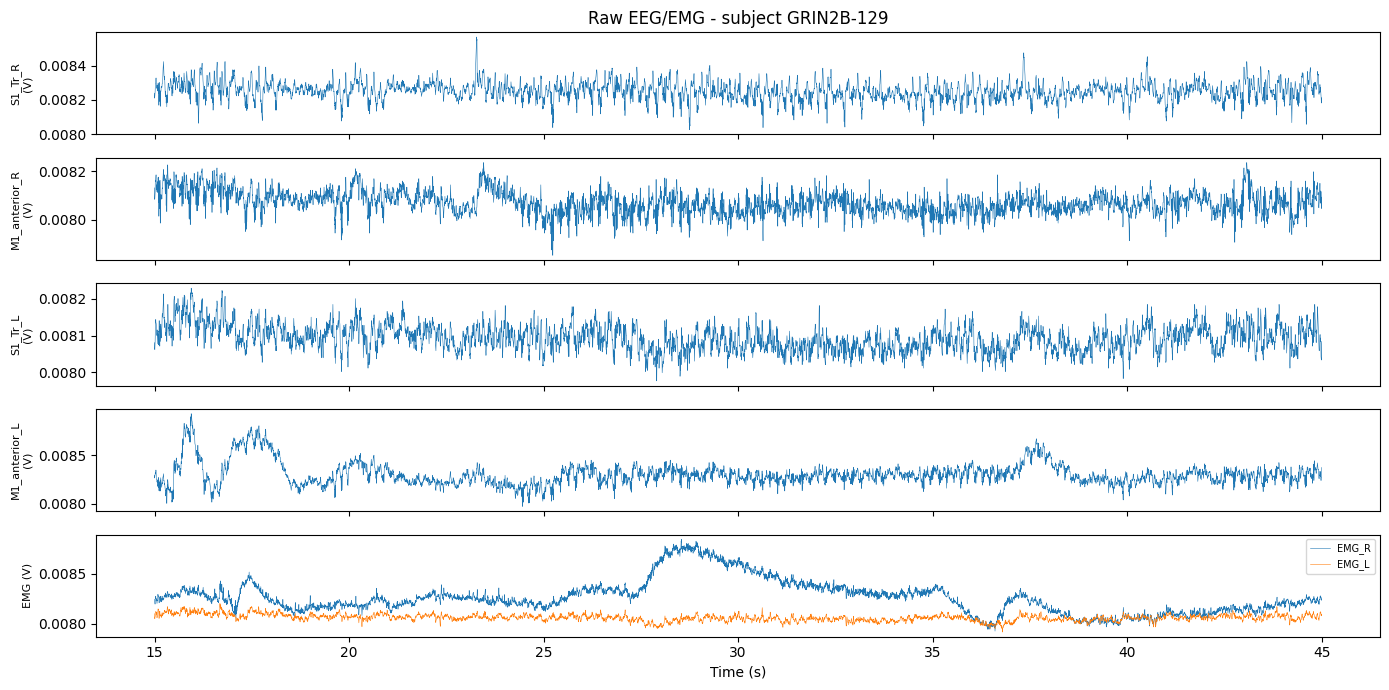

In [4]:
fs = eeg_es.rate
window_start_s = 15
window_duration_s = 30
window_end_s = window_start_s + window_duration_s

i_start = int(window_start_s * fs)
i_end   = int(window_end_s   * fs)

# Convert raw int16 ADC counts to volts using the confirmed TainiTec gain
# (es.conversion is in volts/count). The full recording is indexed directly
eeg_slice = eeg_es.data[i_start:i_end, :] * eeg_es.conversion  # lazy HDF5 read
emg_slice = emg_es.data[i_start:i_end, :] * emg_es.conversion # lazy HDF5 read

t = eeg_es.get_timestamps()[i_start:i_end]

# EEG channels: indices within EEGElectricalSeries (14 channels) — pick a bilateral pair
eeg_idx = {"S1_Tr_R": 0, "M1_anterior_R": 3, "S1_Tr_L": 13, "M1_anterior_L": 10}
# EMG channels: indices within EMGElectricalSeries (2 channels)
emg_idx = {"EMG_R": 0, "EMG_L": 1}

fig, axes = plt.subplots(len(eeg_idx) + 1, 1, figsize=(14, 7), sharex=True)

for ax, (label, idx) in zip(axes[:-1], eeg_idx.items()):
    ax.plot(t, eeg_slice[:, idx], lw=0.4)
    ax.set_ylabel(f"{label}\n(V)", fontsize=8)

ax_emg = axes[-1]
for label, idx in emg_idx.items():
    ax_emg.plot(t, emg_slice[:, idx], lw=0.4, label=label)
ax_emg.set_ylabel("EMG (V)", fontsize=8)
ax_emg.legend(fontsize=7, loc="upper right")
ax_emg.set_xlabel(f"Time (s)")

axes[0].set_title(f"Raw EEG/EMG - subject {nwb.subject.subject_id}")
plt.tight_layout()
plt.show()

## 3. Sleep-state epochs

5-second scored epochs in `processing/behavior/sleep_states_baseline_window_1` (BL1; BL2 is
`sleep_states_baseline_window_2`).
State codes (confirmed by lab): 0 = Wake, 1 = NREM, 2 = REM. State 4 = SWD (see section 6)

In [5]:
behavior = nwb.processing["behavior"]
sleep_baseline_window_1 = behavior["sleep_states_baseline_window_1"]
sleep_df_bl1 = sleep_baseline_window_1.to_dataframe()
sleep_baseline_window_2 = behavior["sleep_states_baseline_window_2"]
sleep_df_bl2 = sleep_baseline_window_2.to_dataframe()


In [6]:
print(
    f"Sleep epochs in the baseline window 1: {len(sleep_df_bl1)} rows (expected 17,280 for full 24 h)"
)
sleep_df_bl1[:]

Sleep epochs in the baseline window 1: 17280 rows (expected 17,280 for full 24 h)


,start_time,stop_time,sleep_score,sleep_state
id,,,,
0,72240.003994,72245.003994,0,Wake
1,72245.003994,72250.003994,0,Wake
2,72250.003994,72255.003994,0,Wake
3,72255.003994,72260.003994,0,Wake
4,72260.003994,72265.003994,0,Wake
...,...,...,...,...
17275,158615.003994,158620.003994,1,NREM
17276,158620.003994,158625.003994,1,NREM
17277,158625.003994,158630.003994,1,NREM


In [7]:
print(
    f"Sleep epochs in the baseline window 2: {len(sleep_df_bl2)} rows (expected 17,280 for full 24 h)"
)
sleep_df_bl2[:]

Sleep epochs in the baseline window 2: 17280 rows (expected 17,280 for full 24 h)


,start_time,stop_time,sleep_score,sleep_state
id,,,,
0,158640.003994,158645.003994,1,NREM
1,158645.003994,158650.003994,1,NREM
2,158650.003994,158655.003994,1,NREM
3,158655.003994,158660.003994,1,NREM
4,158660.003994,158665.003994,1,NREM
...,...,...,...,...
17275,245015.003994,245020.003994,0,Wake
17276,245020.003994,245025.003994,0,Wake
17277,245025.003994,245030.003994,0,Wake


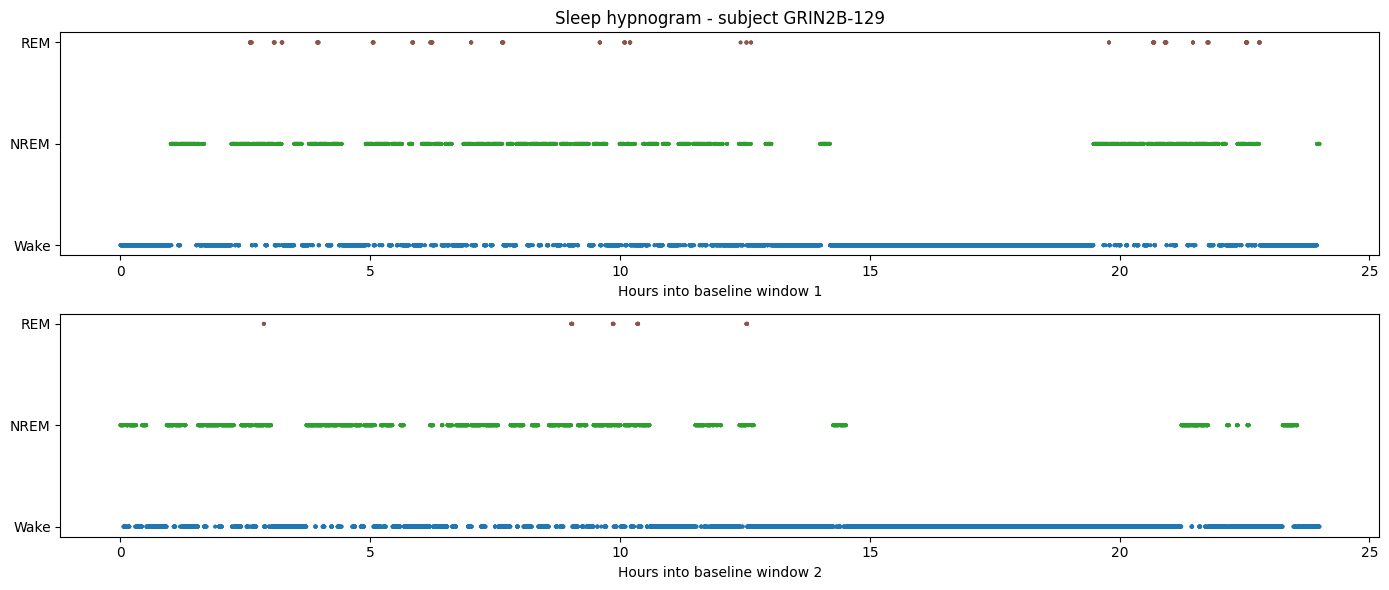

In [ ]:
# Sleep hypnogram
state_labels = {0: "Wake", 1: "NREM", 2: "REM", 4: "SWD"}
t_mid = (sleep_df_bl1["start_time"] + sleep_df_bl1["stop_time"]) / 2
hours = (t_mid - bl1_start_time) / 3600  # hours into BL1 window

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].scatter(
    hours,
    sleep_df_bl1["sleep_score"],
    s=3,
    c=sleep_df_bl1["sleep_score"],
    cmap="tab10",
    vmin=0,
    vmax=4,
)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Wake", "NREM", "REM"])
axes[0].set_xlabel("Hours into baseline window 1")
axes[1].scatter(
    hours,
    sleep_df_bl2["sleep_score"],
    s=3,
    c=sleep_df_bl2["sleep_score"],
    cmap="tab10",
    vmin=0,
    vmax=4,
)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["Wake", "NREM", "REM"])
axes[1].set_xlabel("Hours into baseline window 2")
axes[0].set_title(f"Sleep hypnogram - subject {nwb.subject.subject_id}")
plt.tight_layout()
plt.show()

## 4. Seizure events

Stored as a `pynwb.epoch.TimeIntervals` table in `processing/behavior/seizure_events_baseline_window_1` (BL1).
The table has one row per seizure event, with `start_time`, `stop_time`, and `duration` columns.

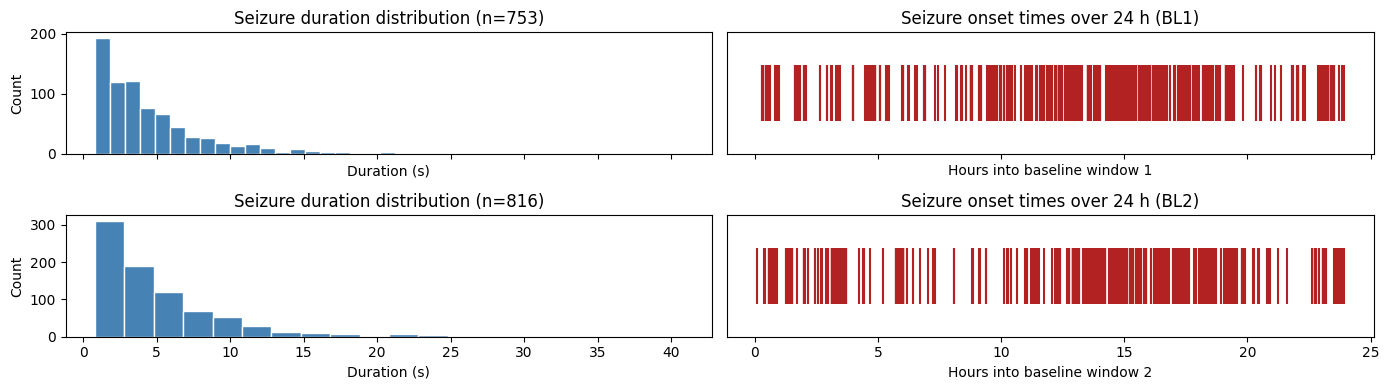

In [28]:
seizure_table = behavior["seizure_events_baseline_window_1"]
seizure_df = seizure_table.to_dataframe()

start_times = seizure_df["start_time"].to_numpy()
stop_times  = seizure_df["stop_time"].to_numpy()
durations   = seizure_df["duration"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 4), sharex="col")

# Duration histogram
axes[0][0].hist(durations, bins=20, color="steelblue", edgecolor="white")
axes[0][0].set_xlabel("Duration (s)")
axes[0][0].set_ylabel("Count")
axes[0][0].set_title(f"Seizure duration distribution (n={len(durations)})")

# Event timeline relative to BL1 window start
rel_start = (start_times - bl1_start_time) / 3600
axes[0][1].eventplot(rel_start, lineoffsets=0, linelengths=0.5, color="firebrick")
axes[0][1].set_xlabel("Hours into baseline window 1")
axes[0][1].set_yticks([])
axes[0][1].set_title("Seizure onset times over 24 h (BL1)")

seizure_table = behavior["seizure_events_baseline_window_2"]
seizure_df = seizure_table.to_dataframe()

start_times = seizure_df["start_time"].to_numpy()
stop_times = seizure_df["stop_time"].to_numpy()
durations = seizure_df["duration"].to_numpy()

# Duration histogram
axes[1][0].hist(durations, bins=20, color="steelblue", edgecolor="white")
axes[1][0].set_xlabel("Duration (s)")
axes[1][0].set_ylabel("Count")
axes[1][0].set_title(f"Seizure duration distribution (n={len(durations)})")

# Event timeline relative to BL1 window start
rel_start = (start_times - bl2_start_time) / 3600
axes[1][1].eventplot(rel_start, lineoffsets=0, linelengths=0.5, color="firebrick")
axes[1][1].set_xlabel("Hours into baseline window 2")
axes[1][1].set_yticks([])
axes[1][1].set_title("Seizure onset times over 24 h (BL2)")

plt.tight_layout()
plt.show()

## 5. Per-epoch SWD counts

`swd_epoch_counts_baseline_window_1` (BL1) is a `TimeSeries` at 0.2 Hz (one value per 5-s sleep epoch).

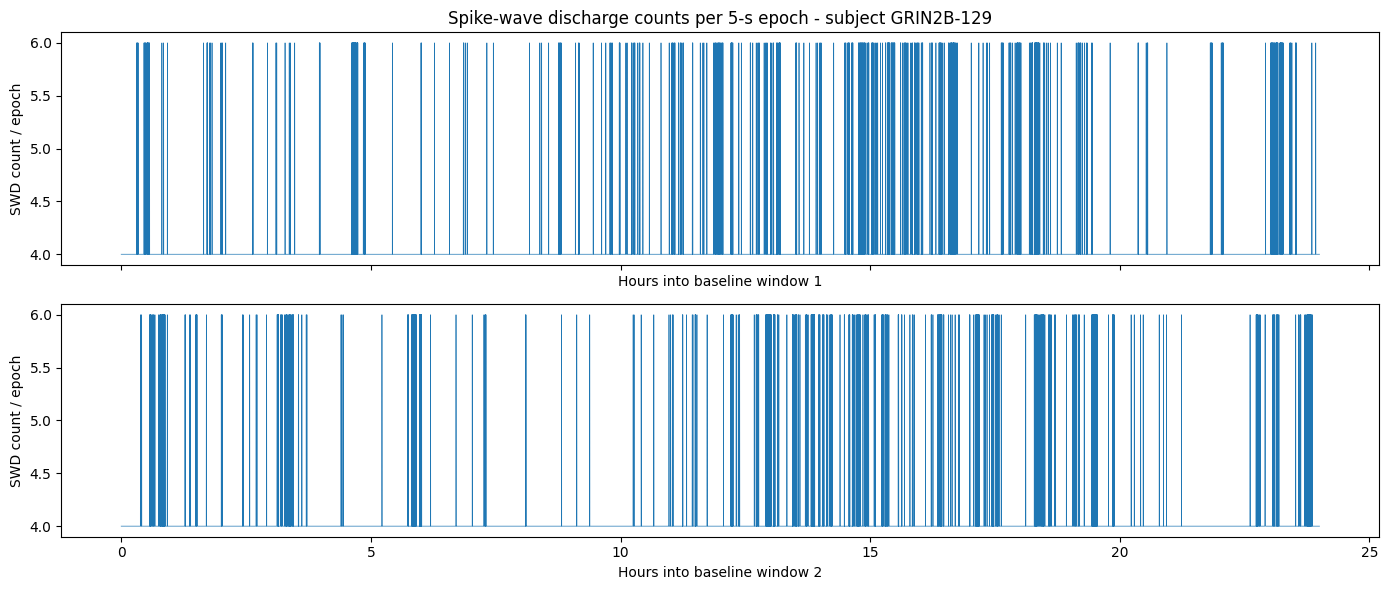

In [30]:
swd = behavior["swd_epoch_counts_baseline_window_1"]
swd_data = swd.data[:]
epoch_times = swd.starting_time + np.arange(len(swd_data)) / swd.rate
hours_swd = (epoch_times - bl1_start_time) / 3600

fig, axes = plt.subplots(2,1, figsize=(14, 6), sharex=True)
axes[0].plot(hours_swd, swd_data, lw=0.5)
axes[0].set_xlabel("Hours into baseline window 1")
axes[0].set_ylabel("SWD count / epoch")
axes[0].set_title(
    f"Spike-wave discharge counts per 5-s epoch - subject {nwb.subject.subject_id}"
)

swd = behavior["swd_epoch_counts_baseline_window_2"]
swd_data = swd.data[:]
epoch_times = swd.starting_time + np.arange(len(swd_data)) / swd.rate
hours_swd = (epoch_times - bl2_start_time) / 3600

axes[1].plot(hours_swd, swd_data, lw=0.5)
axes[1].set_xlabel("Hours into baseline window 2")
axes[1].set_ylabel("SWD count / epoch")

plt.tight_layout()
plt.show()

## 6. Per-sleep-state power spectra

628 frequency bins (0→125.2 Hz, 0.2 Hz steps = Nyquist of 250.4 Hz), in
`processing/ecephys/sleep_state_power_spectra_baseline_window_1` (BL1).
Columns are named directly after the brain state — `Wake`, `NREM`, `REM`, `SWD`
(Spike-and-Wave Discharges, the EEG correlate of absence seizures) — rather
than the raw `s_0`/`s_1`/`s_2`/`s_4` CSV column names.

In [31]:
ecephys = nwb.processing["ecephys"]
psd_table_bl1 = ecephys["sleep_state_power_spectra_baseline_window_1"]
psd_df_bl1 = psd_table_bl1.to_dataframe()
psd_table_bl2 = ecephys["sleep_state_power_spectra_baseline_window_2"]
psd_df_bl2 = psd_table_bl2.to_dataframe()


In [32]:
print(f"PSD table: {psd_df_bl1.shape}")
psd_df_bl1[:]

PSD table: (627, 5)


,frequency_hz,Wake,NREM,REM,SWD
id,,,,,
0,0.0,0.519809,0.539314,0.123515,0.634967
1,0.2,0.497687,0.535483,0.108808,0.614226
2,0.4,0.483442,0.558114,0.093001,0.598746
3,0.6,0.453522,0.574946,0.070813,0.554426
4,0.8,0.439977,0.590124,0.068346,0.537512
...,...,...,...,...,...
622,124.4,0.042762,0.004024,0.005191,0.070005
623,124.6,0.042678,0.004111,0.005180,0.070263
624,124.8,0.042597,0.004328,0.005418,0.070568


In [33]:
print(f"PSD table: {psd_df_bl2.shape}")
psd_df_bl2[:]

PSD table: (627, 5)


,frequency_hz,Wake,NREM,REM,SWD
id,,,,,
0,0.0,0.864452,0.935737,0.533670,1.050656
1,0.2,0.875762,0.965950,0.550871,1.060105
2,0.4,0.907634,1.033543,0.585353,1.090748
3,0.6,1.020505,1.194127,0.702763,1.190375
4,0.8,1.070288,1.274803,0.764896,1.238579
...,...,...,...,...,...
622,124.4,0.046641,0.006989,0.006511,0.096875
623,124.6,0.046434,0.007045,0.006427,0.096319
624,124.8,0.046176,0.007037,0.006313,0.095381


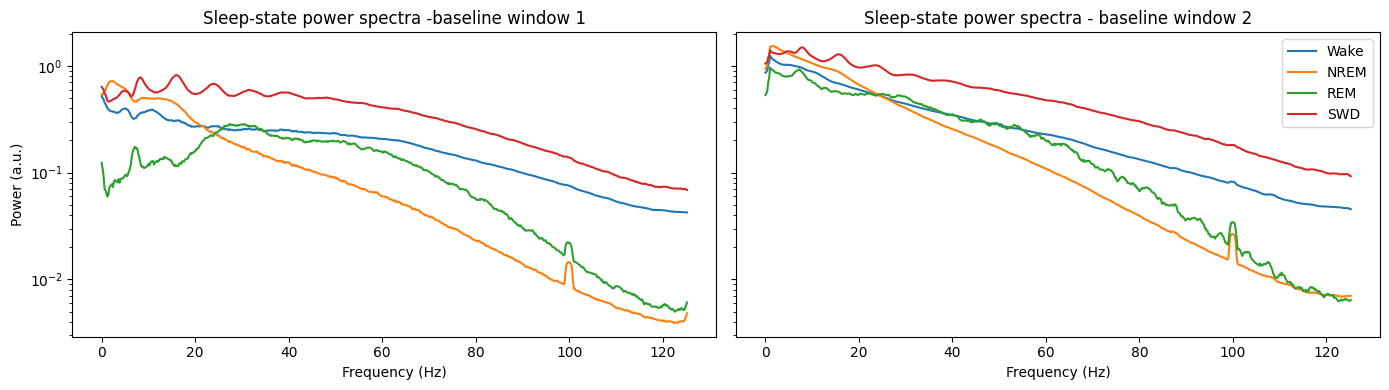

In [37]:
fig, axes = plt.subplots(1,2,figsize=(14, 4),sharey=True)
state_cols = ["Wake", "NREM", "REM", "SWD"]
for col in state_cols:
    if col in psd_df_bl1.columns:
        axes[0].semilogy(psd_df_bl1["frequency_hz"], psd_df_bl1[col], label=col)
# ax.set_xlim(0, 50)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power (a.u.)")
axes[0].set_title("Sleep-state power spectra -baseline window 1")
# axes[0].legend()
for col in state_cols:
    if col in psd_df_bl2.columns:
        axes[1].semilogy(psd_df_bl2["frequency_hz"], psd_df_bl2[col], label=col)
# ax.set_xlim(0, 50)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Sleep-state power spectra - baseline window 2")
axes[1].legend()

plt.tight_layout()
plt.show()